### Notebook to plot static stability characteristics (and CFADs) from BOWTIE sounding data.

James Ruppert  
jruppert@ou.edu  
8/19/24

### Main settings

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc, colors, ticker
import matplotlib.dates as mdates
from thermo_functions import *
import cmocean
import xarray as xr
import pandas as pd
import seaborn as sns
# import scipy.stats as stats
from time_series_diag import *
from orcestra_read_data import *
from vertical_int import *

In [2]:
# Soundings
# snd_asc, snd_files, times_asc = read_bowtie_soundings(search_string = 'ascen')
# # soundings, snd_files, times_snd = read_bowtie_soundings(search_string = 'descen')
snd_asc = read_soundings(platform='RV_Meteor')
hght = snd_asc['hght']
times_asc = snd_asc['times']

### Compute diagnostics

In [3]:
# Vertical smoothing function
def vert_smooth(invar, nz_smooth=10):
    invar_pd = pd.DataFrame(invar)
    invar_pd = (invar_pd.transpose()).rolling(window=nz_smooth, center=True, closed='both', min_periods=3).mean()
    return np.squeeze(np.array(invar_pd).transpose())

In [4]:
# Constants
cp=1004.  # J/K/kg
cpl=4186. # J/k/kg
cpv=1885. # J/K/kg
lv0=2.5e6 # J/kg
g = 9.81 # m/s2
# Latent heat of vaporization
lv = lv0 - (cpl-cpv)*(snd_asc['tmpk']-273.15)

minpres=50e2 # Upper pressure bound for vertical integrals [Pa]

# MSE
dse = cp*snd_asc['tmpk'] + g*hght[np.newaxis,:]
lvq= lv*snd_asc['mr']
mse = dse + lvq

# Static stability
theta = theta_dry(snd_asc['tmpk'], snd_asc['p'])
# for ido in range(3):
theta = vert_smooth(theta, nz_smooth=10)
dthdz = np.gradient(theta, hght, axis=1) # K/m
dthdz = vert_smooth(dthdz, nz_smooth=10)

# tmpk_ddz = np.copy(snd_asc['tmpk'])
# for ido in range(3):
#     tmpk_ddz = smooth_theta(tmpk_ddz, nz_smooth=10)
# dtdz = np.gradient(tmpk_ddz, hght, axis=1) # K/m
# dtdz = smooth_theta(dtdz, nz_smooth=20)

# CWV/PW
# 1/g int(q)dp = s2/m * kg/m/s2 --> kg/m2 --> x1/rho_l --> 10^-3 kg/m2*m3/kg --> 10^-3m = mm
# int<q*rho>dz = kg/m3*m = kg/m2 = mm
cwv = vert_integral(snd_asc) # mm or kg/m2

---
### Plotting routines

#### Plot functions

In [8]:
font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 12}

rc('font', **font)

# sns.set_theme(style="darkgrid", rc={'xtick.bottom': True, 'ytick.left': True,})

#### CFADS

##### Hexbin plots, binning by z vs T

In [9]:
# Create dataframe from snd_asc

time_2d, height_2d = np.meshgrid(times_asc, hght, indexing='ij')  # same shape (nt, nz)

relh = calc_relh(snd_asc['mr'], snd_asc['p'], snd_asc['tmpk'], ice=True)

df_snd = pd.DataFrame({
    'time': time_2d.flatten(),
    'hght': height_2d.flatten(),
    'tmpc': snd_asc['tmpk'].flatten()-273.15,
    'relh': relh.flatten(),
    'dthdz': dthdz.flatten()*1e3
})

# Remove NaNs
df_snd = df_snd.dropna(subset=['dthdz', 'tmpc', 'relh'])

/var/folders/9x/209ltwrn2b359nrrh4638hv40000gp/T/ipykernel_33662/3841434545.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned = (df_snd.groupby(pd.cut(df_snd['hght']*1e-3, bins=bins))


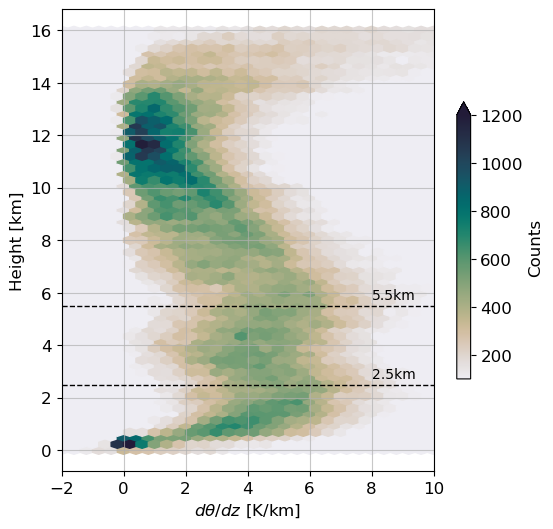

In [30]:
plt.figure(figsize=(6, 6))
plt.hexbin(df_snd['dthdz'], df_snd['hght']*1e-3,
            gridsize=[35,35],
            extent=(-2,12,0,16),
            cmap=cmocean.cm.rain,
            vmin=100, vmax=1200)

# Identify local maxima in temperature bins
bins = np.arange(0, 20, 0.5)  # Define bins
df_binned = (df_snd.groupby(pd.cut(df_snd['hght']*1e-3, bins=bins))
             .agg(mean_dthdz=('dthdz', 'mean'))
             .reset_index())

# Step 2: Find local maxima in the mean dthdz values
from scipy.signal import find_peaks
mean_dthdz_values = df_binned['mean_dthdz'].values
peaks, _ = find_peaks(mean_dthdz_values)
for peak in peaks[1:-1]:
    value = bins[peak]
    plt.axhline(y=value, color='black', linestyle='--', linewidth=1)
    # Plot T value
    plt.text(8, value+0.25, f'{value}km', color='black', fontsize=10)

plt.colorbar(label='Counts', shrink=0.6, extend='max')
plt.xlabel(r'$d\theta/dz$ [K/km]')
# invert y-axis
# plt.gca().invert_yaxis()
plt.xlim(-2, 10)
plt.ylabel('Height [km]')
plt.grid(True, alpha=0.7)
plt.show()

/var/folders/9x/209ltwrn2b359nrrh4638hv40000gp/T/ipykernel_33662/3811866155.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_binned = (df_snd.groupby(pd.cut(df_snd['tmpc'], bins=bins))


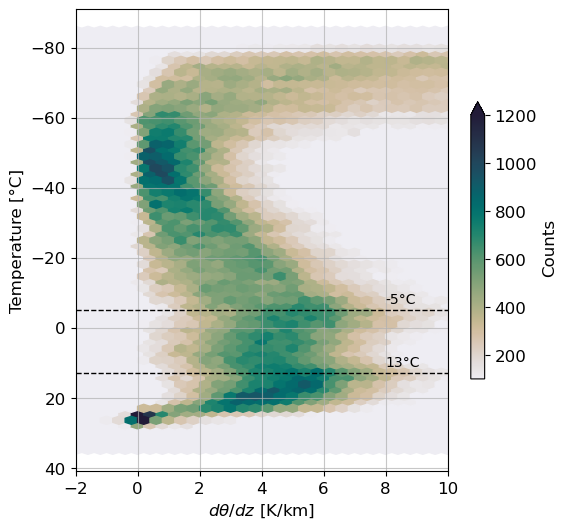

In [29]:
plt.figure(figsize=(6, 6))
plt.hexbin(df_snd['dthdz'], df_snd['tmpc'],
            gridsize=[35,35],
            extent=(-2,12,-85,35),
            cmap=cmocean.cm.rain,
            vmin=100, vmax=1200)

# Identify local maxima in temperature bins
bins = np.arange(-85, 40, 2)  # Define temperature bins
df_binned = (df_snd.groupby(pd.cut(df_snd['tmpc'], bins=bins))
             .agg(mean_dthdz=('dthdz', 'mean'))
             .reset_index())

# Step 2: Find local maxima in the mean dthdz values
from scipy.signal import find_peaks
mean_dthdz_values = df_binned['mean_dthdz'].values
peaks, _ = find_peaks(mean_dthdz_values)
for peak in peaks[[3,4]]:
    value = bins[peak]
    plt.axhline(y=value, color='black', linestyle='--', linewidth=1)
    # Plot T value
    plt.text(8, value-2, f'{value}°C', color='black', fontsize=10)

plt.colorbar(label='Counts', shrink=0.6, extend='max')
plt.xlabel(r'$d\theta/dz$ [K/km]')
# invert y-axis
plt.gca().invert_yaxis()
plt.xlim(-2, 10)
plt.ylabel('Temperature [°C]')
plt.grid(True, alpha=0.7)
plt.show()

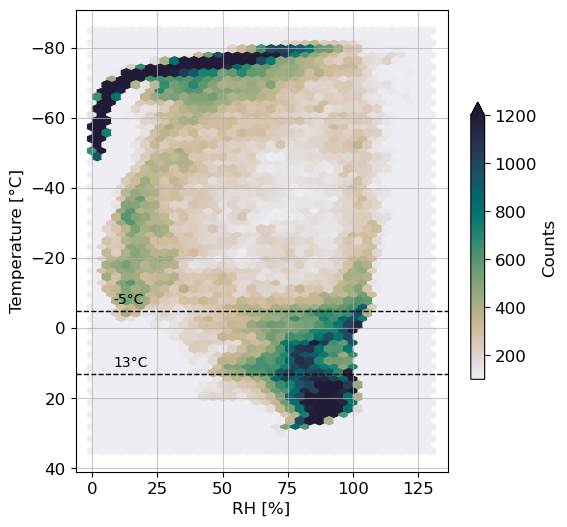

In [11]:
plt.figure(figsize=(6, 6))
plt.hexbin(df_snd['relh'], df_snd['tmpc'],
            gridsize=[35,35],
            extent=(0,130,-85,35),
            cmap=cmocean.cm.rain,
            vmin=100, vmax=1200)

# # Identify local maxima in temperature bins
# temp_bins = np.arange(-85, 40, 2)  # Define temperature bins
# df_binned = (df_snd.groupby(pd.cut(df_snd['tmpc'], bins=temp_bins))
#              .agg(mean_dthdz=('dthdz', 'mean'))
#              .reset_index())

# # Step 2: Find local maxima in the mean dthdz values
# from scipy.signal import find_peaks
# mean_dthdz_values = df_binned['mean_dthdz'].values
# peaks, _ = find_peaks(mean_dthdz_values)
for peak in peaks[[3,4]]:
    temp_value = temp_bins[peak]
    plt.axhline(y=temp_value, color='black', linestyle='--', linewidth=1)
    # Plot T value
    plt.text(8, temp_value-2, f'{temp_value}°C', color='black', fontsize=10)

plt.colorbar(label='Counts', shrink=0.6, extend='max')
plt.xlabel('RH [%]')
# invert y-axis
plt.gca().invert_yaxis()
# plt.xlim(-2, 10)
plt.ylabel('Temperature [°C]')
plt.grid(True, alpha=0.7)
plt.show()